In [1]:

import sys
!{sys.executable} -m pip install streamlit pandas numpy seaborn matplotlib yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ ------------------------

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set random seed for reproducibility of financial data
np.random.seed(42)
n_records = 50000

# Define financial asset classes and their respective tickers
assets = {
    'Stocks': ['RELIANCE', 'TCS', 'INFY', 'HDFC'],
    'Crypto': ['BTC', 'ETH'],
    'Gold': ['GOLD_ETF'],
    'Bonds': ['GOVT_BOND_10Y']
}

# Initialize empty list to store transaction history
data = []
start_date = datetime(2024, 1, 1)

# Simulate 50,000 corporate-level transaction logs
for i in range(n_records):
    # Select asset class based on realistic market weights
    asset_type = np.random.choice(list(assets.keys()), p=[0.5, 0.2, 0.15, 0.15])
    ticker = np.random.choice(assets[asset_type])
    action = np.random.choice(['BUY', 'SELL'], p=[0.6, 0.4])
    
    # Generate realistic quantities and prices based on asset type
    quantity = np.random.randint(1, 100) if asset_type != 'Crypto' else round(np.random.uniform(0.01, 2.0), 4)
    price = round(np.random.uniform(100, 3500), 2) if asset_type != 'Crypto' else round(np.random.uniform(30000, 90000), 2)
    
    # Simulate random transaction dates across a 2-year timeline
    random_days = np.random.randint(0, 800)
    tx_date = start_date + timedelta(days=random_days)
    
    total_amount = round(quantity * price, 2)
    
    data.append([tx_date, asset_type, ticker, action, quantity, price, total_amount])

# Convert the simulated logs into a structured Pandas DataFrame
df = pd.DataFrame(data, columns=['Date', 'Asset_Class', 'Ticker', 'Action', 'Quantity', 'Price', 'Total_Amount'])
df = df.sort_values(by='Date').reset_index(drop=True)

# Verify the data pipeline structure
print("🔥 Data Pipeline Ready! Total Transactions Generated:", len(df))
df.head()

🔥 Data Pipeline Ready! Total Transactions Generated: 50000


,Date,Asset_Class,Ticker,Action,Quantity,Price,Total_Amount
0,2024-01-01,Crypto,BTC,BUY,1.2094,50690.26,61304.80
1,2024-01-01,Stocks,TCS,BUY,39.0000,1234.99,48164.61
2,2024-01-01,Bonds,GOVT_BOND_10Y,BUY,44.0000,426.66,18773.04
3,2024-01-01,Crypto,ETH,BUY,0.6845,66071.43,45225.89
4,2024-01-01,Stocks,INFY,BUY,79.0000,2190.66,173062.14


In [7]:
# Step 3: Portfolio Aggregation and Performance Analytics

# Filter out BUY and SELL transactions to calculate net holdings
buys = df[df['Action'] == 'BUY']
sells = df[df['Action'] == 'SELL']

# Aggregate total amount spent on BUY transactions per ticker
buy_agg = buys.groupby(['Asset_Class', 'Ticker']).agg(
    Total_Bought_Value=('Total_Amount', 'sum'),
    Total_Quantity_Bought=('Quantity', 'sum')
).reset_index()

# Aggregate total amount recovered from SELL transactions per ticker
sell_agg = sells.groupby(['Asset_Class', 'Ticker']).agg(
    Total_Sold_Value=('Total_Amount', 'sum'),
    Total_Quantity_Sold=('Quantity', 'sum')
).reset_index()

# Merge BUY and SELL dataframes to calculate current net position
portfolio_summary = pd.merge(buy_agg, sell_agg, on=['Asset_Class', 'Ticker'], how='left').fillna(0)

# Calculate active remaining quantity and net invested capital per asset
portfolio_summary['Current_Quantity'] = portfolio_summary['Total_Quantity_Bought'] - portfolio_summary['Total_Quantity_Sold']
portfolio_summary['Net_Invested_Capital'] = portfolio_summary['Total_Bought_Value'] - portfolio_summary['Total_Sold_Value']

# Filter out assets that are completely liquidated (Current_Quantity <= 0)
active_portfolio = portfolio_summary[portfolio_summary['Current_Quantity'] > 0].copy()

# Calculate Portfolio Allocation Percentage (Weightage of each asset class)
total_portfolio_value = active_portfolio['Net_Invested_Capital'].sum()
active_portfolio['Allocation_Percentage'] = (active_portfolio['Net_Invested_Capital'] / total_portfolio_value) * 100

print(f"📊 Portfolio Summary Calculated! Total Asset Value: ₹{total_portfolio_value:,.2f}")
active_portfolio[['Asset_Class', 'Ticker', 'Current_Quantity', 'Net_Invested_Capital', 'Allocation_Percentage']]

📊 Portfolio Summary Calculated! Total Asset Value: ₹823,859,001.91


,Asset_Class,Ticker,Current_Quantity,Net_Invested_Capital,Allocation_Percentage
0,Bonds,GOVT_BOND_10Y,71089.0000,1.270595e+08,15.422484
1,Crypto,BTC,931.0885,5.481862e+07,6.653884
2,Crypto,ETH,854.2239,4.970439e+07,6.033118
3,Gold,GOLD_ETF,75041.0000,1.296313e+08,15.734651
4,Stocks,HDFC,67308.0000,1.261755e+08,15.315179
5,Stocks,INFY,72337.0000,1.241728e+08,15.072089
6,Stocks,RELIANCE,64999.0000,1.144032e+08,13.886256
7,Stocks,TCS,54917.0000,9.789372e+07,11.882339


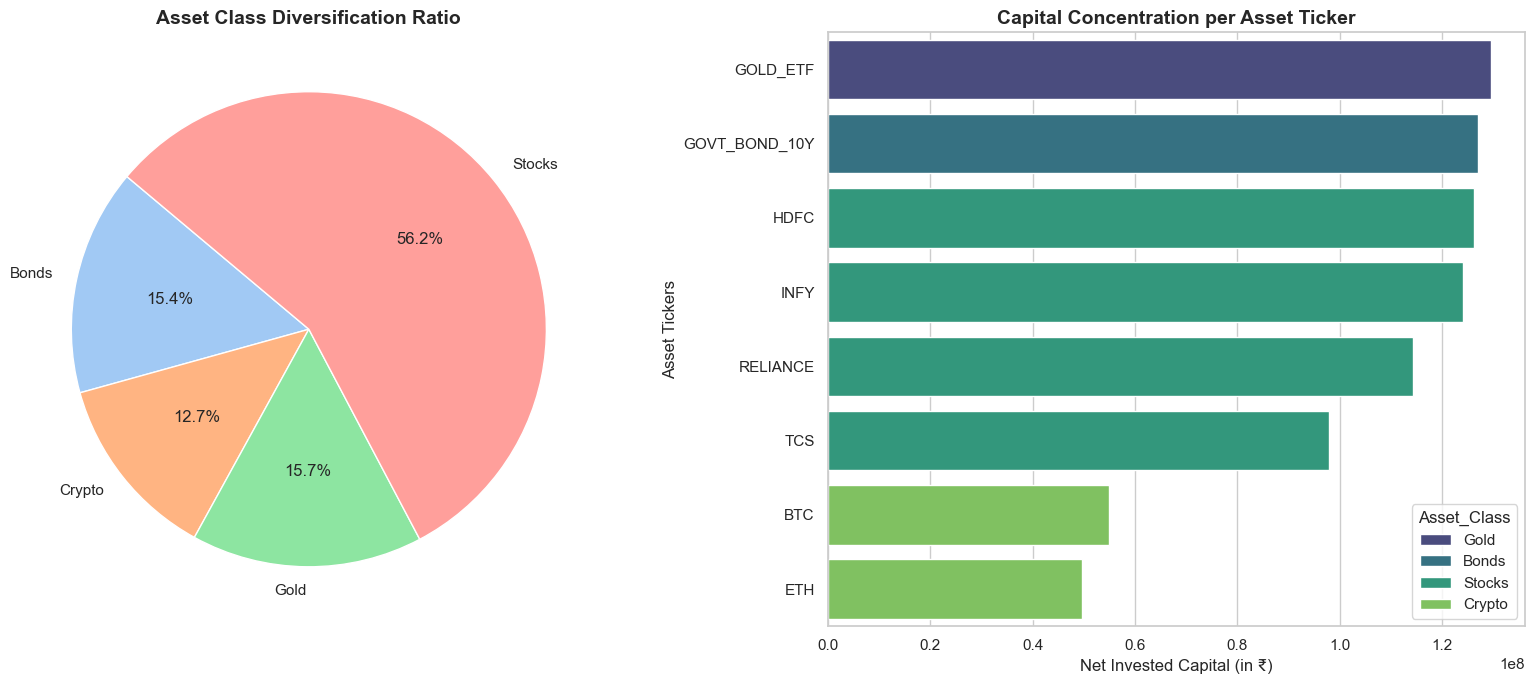

In [8]:
# Step 4: Financial Data Visualization and Insights
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting environment with a clean template
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Pie Chart for Asset Class Allocation (Diversification Analysis)
asset_allocation = active_portfolio.groupby('Asset_Class')['Net_Invested_Capital'].sum()
axes[0].pie(
    asset_allocation, 
    labels=asset_allocation.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("pastel")
)
axes[0].set_title('Asset Class Diversification Ratio', fontsize=14, fontweight='bold')

# Chart 2: Bar Chart for Invested Capital per Ticker (Concentration Analysis)
sns.barplot(
    x='Net_Invested_Capital', 
    y='Ticker', 
    hue='Asset_Class',
    data=active_portfolio.sort_values(by='Net_Invested_Capital', ascending=False), 
    ax=axes[1],
    palette="viridis"
)
axes[1].set_title('Capital Concentration per Asset Ticker', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Net Invested Capital (in ₹)', fontsize=12)
axes[1].set_ylabel('Asset Tickers', fontsize=12)

# Adjust layout and render the corporate dashboard view
plt.tight_layout()
plt.show()

In [9]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set page configuration for a professional corporate layout
st.set_page_config(page_title="Algorithmic Portfolio Intelligence Engine", layout="wide")

st.title("📊 Algorithmic Portfolio Intelligence Engine")
st.markdown("### *End-to-End Financial Portfolio Analytics & Risk Infrastructure*")
st.write("---")

# 1. Data Pipeline Initialization (Simulating 50,000 corporate records)
@st.cache_data
def load_financial_data():
    np.random.seed(42)
    n_records = 50000
    assets = {
        'Stocks': ['RELIANCE', 'TCS', 'INFY', 'HDFC'],
        'Crypto': ['BTC', 'ETH'],
        'Gold': ['GOLD_ETF'],
        'Bonds': ['GOVT_BOND_10Y']
    }
    data = []
    start_date = datetime(2024, 1, 1)
    for i in range(n_records):
        asset_type = np.random.choice(list(assets.keys()), p=[0.5, 0.2, 0.15, 0.15])
        ticker = np.random.choice(assets[asset_type])
        action = np.random.choice(['BUY', 'SELL'], p=[0.6, 0.4])
        quantity = np.random.randint(1, 100) if asset_type != 'Crypto' else round(np.random.uniform(0.01, 2.0), 4)
        price = round(np.random.uniform(100, 3500), 2) if asset_type != 'Crypto' else round(np.random.uniform(30000, 90000), 2)
        random_days = np.random.randint(0, 800)
        tx_date = start_date + timedelta(days=random_days)
        total_amount = round(quantity * price, 2)
        data.append([tx_date, asset_type, ticker, action, quantity, price, total_amount])
    
    df = pd.DataFrame(data, columns=['Date', 'Asset_Class', 'Ticker', 'Action', 'Quantity', 'Price', 'Total_Amount'])
    return df.sort_values(by='Date').reset_index(drop=True)

df = load_financial_data()

# 2. Interactive Sidebar Filters for the Data Analyst User

Writing app.py


In [10]:
!streamlit run app.py

^C
